<a href="https://colab.research.google.com/github/Wizako-01/A-Comparative-Study-of-Convolutional-Neural-Networks-and-ViT-for-Cervical-Cytology-Classification/blob/main/Herlve_dataset_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("niladrishekharray/herlev-pap-smear-2005")

print("Path to dataset files:", path)

100%|██████████| 41.6M/41.6M [00:00<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/niladrishekharray/herlev-pap-smear-2005/versions/1


In [3]:
# Define a permanent project folder
import os
project_path = "/content/drive/MyDrive/Herlev_Project"
if not os.path.exists(project_path):
    os.makedirs(project_path)
    print(f"Created project folder at: {project_path}")

In [4]:
import shutil
import glob

def move_to_drive(source_path, dest_path):
    # Find all subdirectories in the downloaded folder
    categories = [d for d in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, d))]

    for cat in categories:
        src_cat_path = os.path.join(source_path, cat)
        dest_cat_path = os.path.join(dest_path, cat)

        if not os.path.exists(dest_cat_path):
            os.makedirs(dest_cat_path)

        # Get only the actual cell images (skip the masks)
        images = [f for f in os.listdir(src_cat_path) if f.endswith('.bmp') and "-d" not in f.lower()]

        for img in images:
            shutil.copy(os.path.join(src_cat_path, img), os.path.join(dest_cat_path, img))

    print(f"Success! Cleaned images moved to {dest_path}")

# Run the move
move_to_drive(path, project_path)

Success! Cleaned images moved to /content/drive/MyDrive/Herlev_Project


In [5]:
import os

# The path to your cleaned images in Drive
project_path = "/content/drive/MyDrive/Herlev_Project"

def get_category_counts(target_path):
    print(f"{'Category Name':<30} | {'Image Count':<12}")
    print("-" * 45)

    # List all subfolders (categories)
    categories = sorted([d for d in os.listdir(target_path) if os.path.isdir(os.path.join(target_path, d))])

    total_images = 0
    for cat in categories:
        cat_folder = os.path.join(target_path, cat)
        # Count only the .bmp files
        count = len([f for f in os.listdir(cat_folder) if f.endswith('.bmp')])
        print(f"{cat:<30} | {count:<12}")
        total_images += count

    print("-" * 45)
    print(f"{'TOTAL':<30} | {total_images:<12}")

get_category_counts(project_path)

Category Name                  | Image Count 
---------------------------------------------
carcinoma_in_situ              | 0           
light_dysplastic               | 0           
moderate_dysplastic            | 0           
normal_columnar                | 0           
normal_intermediate            | 0           
normal_superficiel             | 0           
severe_dysplastic              | 0           
---------------------------------------------
TOTAL                          | 0           


In [6]:
import os

# Let's find where the actual folders are
for root, dirs, files in os.walk(path):
    if len(dirs) > 0:
        print(f"Found folders at: {root}")
        print(f"Folders are: {dirs}")
        break # We just need the first level of structure

Found folders at: /root/.cache/kagglehub/datasets/niladrishekharray/herlev-pap-smear-2005/versions/1
Folders are: ['normal_superficiel', 'severe_dysplastic', 'moderate_dysplastic', 'normal_intermediate', 'light_dysplastic', 'carcinoma_in_situ', 'normal_columnar']


In [7]:
import os
import shutil

# 1. Setup paths
source_root = "/root/.cache/kagglehub/datasets/niladrishekharray/herlev-pap-smear-2005/versions/1"
drive_dest = "/content/drive/MyDrive/Herlev_Project"

# 2. Categories from your output
categories = [
    'light_dysplastic', 'normal_superficiel', 'moderate_dysplastic',
    'normal_columnar', 'normal_intermediate', 'severe_dysplastic',
    'carcinoma_in_situ'
]

print(f"{'Category':<25} | {'Images Moved':<10}")
print("-" * 40)

total_moved = 0
for cat in categories:
    src_path = os.path.join(source_root, cat)
    dst_path = os.path.join(drive_dest, cat)

    if not os.path.exists(dst_path):
        os.makedirs(dst_path)

    # Get all .bmp files but ignore the masks (-d files)
    images = [f for f in os.listdir(src_path) if f.lower().endswith('.bmp') and "-d" not in f.lower()]

    for img in images:
        shutil.copy(os.path.join(src_path, img), os.path.join(dst_path, img))

    print(f"{cat:<25} | {len(images):<10}")
    total_moved += len(images)

print("-" * 40)
print(f"{'TOTAL':<25} | {total_moved:<10}")

Category                  | Images Moved
----------------------------------------
light_dysplastic          | 182       
normal_superficiel        | 74        
moderate_dysplastic       | 146       
normal_columnar           | 98        
normal_intermediate       | 70        
severe_dysplastic         | 197       
carcinoma_in_situ         | 150       
----------------------------------------
TOTAL                     | 917       


In [8]:
# Install the split-folders utility if not already installed
!pip install split-folders

import splitfolders
import os

# Input path: Your cleaned images
input_folder = "/content/drive/MyDrive/Herlev_Project"

# Output path: The structured folders for training
output_folder = "/content/drive/MyDrive/Herlev_Final_Split"

# Split with a fixed seed (1337) so your experiment is reproducible
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.7, .15, .15))

print("Split complete! Your folders are ready at:", output_folder)

Copying files: 917 files [05:25,  2.81 files/s]

Split complete! Your folders are ready at: /content/drive/MyDrive/Herlev_Final_Split


In [9]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# 1. Define Transformations
# Training needs augmentation; Validation/Test only needs resizing and normalization
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet standards
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Load Datasets
data_dir = "/content/drive/MyDrive/Herlev_Final_Split"

train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=val_test_transforms)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_test_transforms)

# 3. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Loaded {len(train_dataset)} training images.")
print(f"Classes found: {train_dataset.classes}")

Loaded 639 training images.
Classes found: ['carcinoma_in_situ', 'light_dysplastic', 'moderate_dysplastic', 'normal_columnar', 'normal_intermediate', 'normal_superficiel', 'severe_dysplastic']


In [10]:
def get_model(model_name, num_classes=7):
    if model_name == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1')
        # Replace the last fully connected layer
        num_ftrs = model.fc.in_features
        model.fc = torch.nn.Linear(num_ftrs, num_classes)

    elif model_name == 'efficientnet':
        model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        # Replace the classifier
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = torch.nn.Linear(num_ftrs, num_classes)

    elif model_name == 'vit':
        model = models.vit_b_16(weights='IMAGENET1K_V1')
        # Replace the heads
        num_ftrs = model.heads.head.in_features
        model.heads.head = torch.nn.Linear(num_ftrs, num_classes)

    return model

# Test initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model('resnet50').to(device)
print(f"ResNet50 initialized on {device}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 125MB/s]


ResNet50 initialized on cuda


In [11]:
import torch.optim as optim
import torch.nn as nn
import time
import copy

def train_model(model, criterion, optimizer, num_epochs=25):
    since = time.time()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # History dictionary to store metrics for plotting
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Save metrics to history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                # Deep copy the model if it has the best validation accuracy
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [14]:
# 1. Initialize Model
model_resnet = get_model('resnet50', num_classes=7)

# 2. Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
# Only optimize the parameters of the final layer (Transfer Learning)
optimizer = optim.Adam(model_resnet.fc.parameters(), lr=0.001)

# 3. Train
trained_resnet, resnet_history = train_model(model_resnet, criterion, optimizer, num_epochs=20)

Epoch 0/19
----------
train Loss: 1.8620 Acc: 0.2676
val Loss: 1.5776 Acc: 0.2761
Epoch 1/19
----------
train Loss: 1.4925 Acc: 0.4319
val Loss: 1.3876 Acc: 0.5299
Epoch 2/19
----------
train Loss: 1.2760 Acc: 0.5243
val Loss: 1.2327 Acc: 0.5746
Epoch 3/19
----------
train Loss: 1.2101 Acc: 0.5305
val Loss: 1.2019 Acc: 0.5821
Epoch 4/19
----------
train Loss: 1.1797 Acc: 0.5430
val Loss: 1.2191 Acc: 0.5373
Epoch 5/19
----------
train Loss: 1.1328 Acc: 0.5634
val Loss: 1.1448 Acc: 0.6045
Epoch 6/19
----------
train Loss: 1.0924 Acc: 0.5884
val Loss: 1.0688 Acc: 0.6642
Epoch 7/19
----------
train Loss: 1.0224 Acc: 0.6119
val Loss: 1.1183 Acc: 0.6194
Epoch 8/19
----------
train Loss: 1.0929 Acc: 0.5915
val Loss: 1.1234 Acc: 0.6194
Epoch 9/19
----------
train Loss: 1.0215 Acc: 0.6182
val Loss: 1.0427 Acc: 0.6493
Epoch 10/19
----------
train Loss: 0.9824 Acc: 0.6119
val Loss: 1.0619 Acc: 0.6045
Epoch 11/19
----------
train Loss: 0.9352 Acc: 0.6401
val Loss: 1.0783 Acc: 0.6119
Epoch 12/19
--

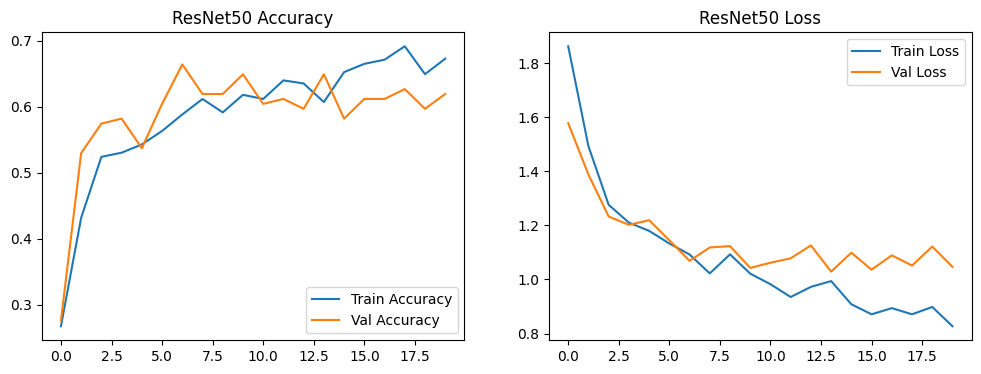

In [15]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()

    plt.show()

plot_history(resnet_history, 'ResNet50')

Classification Report:
                     precision    recall  f1-score   support

  carcinoma_in_situ       0.68      0.57      0.62        23
   light_dysplastic       0.68      0.68      0.68        28
moderate_dysplastic       0.38      0.39      0.38        23
    normal_columnar       0.60      0.56      0.58        16
normal_intermediate       0.79      1.00      0.88        11
 normal_superficiel       1.00      0.83      0.91        12
  severe_dysplastic       0.50      0.55      0.52        31

           accuracy                           0.61       144
          macro avg       0.66      0.65      0.65       144
       weighted avg       0.62      0.61      0.61       144



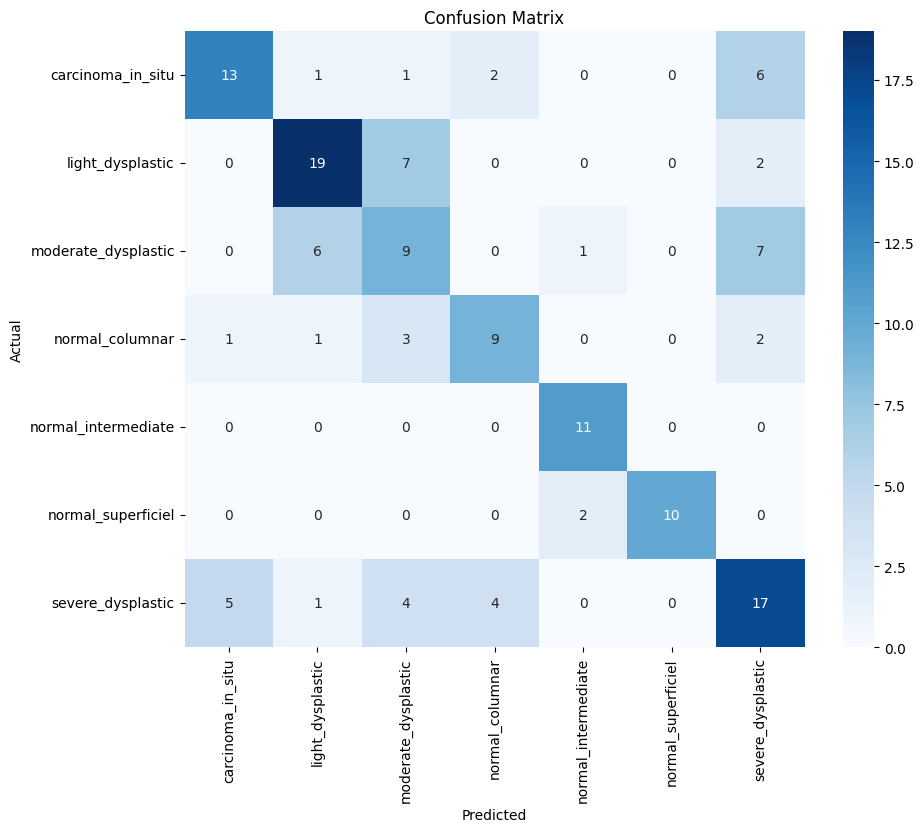

In [16]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

def evaluate_model(model, test_loader, classes):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Classification Report (F1, Precision, Recall)
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# Run evaluation for your trained ResNet (or swap for others)
evaluate_model(trained_resnet, test_loader, train_dataset.classes)

EFFICIENT NET


In [17]:
# 1. Setup EfficientNet
model_eff = get_model('efficientnet', num_classes=7)

# 2. Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()

# Note: For EfficientNet, the head is model.classifier[1]
optimizer = optim.Adam(model_eff.classifier[1].parameters(), lr=0.001)

# 3. Train the model
# Using the same function from our previous step for a fair comparison
trained_eff, eff_history = train_model(model_eff, criterion, optimizer, num_epochs=20)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 77.9MB/s]


Epoch 0/19
----------
train Loss: 1.6797 Acc: 0.3552
val Loss: 1.4824 Acc: 0.4627
Epoch 1/19
----------
train Loss: 1.3416 Acc: 0.5039
val Loss: 1.3039 Acc: 0.5448
Epoch 2/19
----------
train Loss: 1.2380 Acc: 0.5462
val Loss: 1.2359 Acc: 0.5970
Epoch 3/19
----------
train Loss: 1.1472 Acc: 0.5822
val Loss: 1.1954 Acc: 0.5896
Epoch 4/19
----------
train Loss: 1.0537 Acc: 0.6166
val Loss: 1.1493 Acc: 0.6045
Epoch 5/19
----------
train Loss: 1.0491 Acc: 0.6009
val Loss: 1.1136 Acc: 0.6194
Epoch 6/19
----------
train Loss: 0.9881 Acc: 0.6228
val Loss: 1.0988 Acc: 0.5896
Epoch 7/19
----------
train Loss: 0.9677 Acc: 0.6463
val Loss: 1.0739 Acc: 0.6045
Epoch 8/19
----------
train Loss: 0.9581 Acc: 0.6557
val Loss: 1.0662 Acc: 0.6045
Epoch 9/19
----------
train Loss: 0.9404 Acc: 0.6541
val Loss: 1.0528 Acc: 0.6493
Epoch 10/19
----------
train Loss: 0.9256 Acc: 0.6541
val Loss: 1.0356 Acc: 0.6269
Epoch 11/19
----------
train Loss: 0.9120 Acc: 0.6776
val Loss: 1.0240 Acc: 0.6567
Epoch 12/19
--

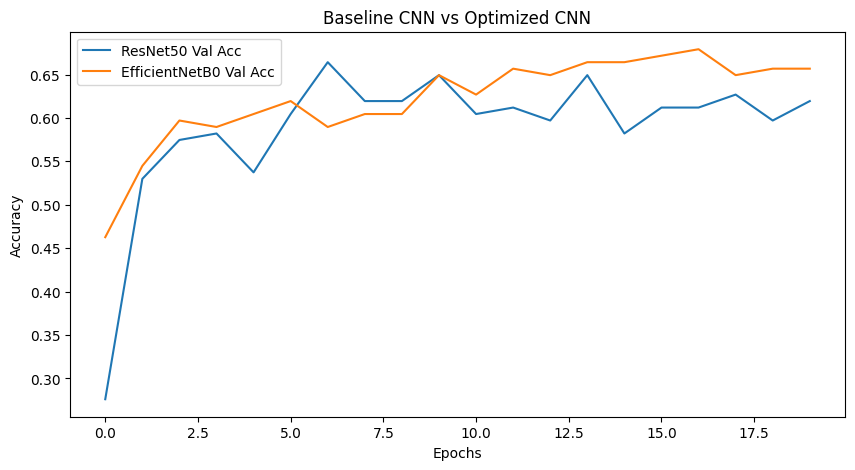

In [18]:
# Compare ResNet vs EfficientNet
plt.figure(figsize=(10, 5))
plt.plot(resnet_history['val_acc'], label='ResNet50 Val Acc')
plt.plot(eff_history['val_acc'], label='EfficientNetB0 Val Acc')
plt.title('Baseline CNN vs Optimized CNN')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [19]:
# 1. Setup Vision Transformer
# We use the standard pre-trained weights for the Base-16 version
model_vit = get_model('vit', num_classes=7)

# 2. Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()

# IMPORTANT: ViT often requires a smaller learning rate than CNNs
# We only train the 'heads' for the initial transfer learning phase
optimizer = optim.Adam(model_vit.heads.head.parameters(), lr=1e-4)

# 3. Train the model
trained_vit, vit_history = train_model(model_vit, criterion, optimizer, num_epochs=20)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 83.9MB/s]


Epoch 0/19
----------
train Loss: 1.8935 Acc: 0.2300
val Loss: 1.8437 Acc: 0.2388
Epoch 1/19
----------
train Loss: 1.7640 Acc: 0.2864
val Loss: 1.7481 Acc: 0.2687
Epoch 2/19
----------
train Loss: 1.6805 Acc: 0.3349
val Loss: 1.6731 Acc: 0.2687
Epoch 3/19
----------
train Loss: 1.6107 Acc: 0.3803
val Loss: 1.6076 Acc: 0.3060
Epoch 4/19
----------
train Loss: 1.5350 Acc: 0.4507
val Loss: 1.5510 Acc: 0.3582
Epoch 5/19
----------
train Loss: 1.4825 Acc: 0.4710
val Loss: 1.5008 Acc: 0.4179
Epoch 6/19
----------
train Loss: 1.4312 Acc: 0.5149
val Loss: 1.4578 Acc: 0.4552
Epoch 7/19
----------
train Loss: 1.3942 Acc: 0.5430
val Loss: 1.4182 Acc: 0.4552
Epoch 8/19
----------
train Loss: 1.3465 Acc: 0.5446
val Loss: 1.3841 Acc: 0.4701
Epoch 9/19
----------
train Loss: 1.3192 Acc: 0.5571
val Loss: 1.3529 Acc: 0.4925
Epoch 10/19
----------
train Loss: 1.2865 Acc: 0.5571
val Loss: 1.3242 Acc: 0.5075
Epoch 11/19
----------
train Loss: 1.2571 Acc: 0.5790
val Loss: 1.3000 Acc: 0.5149
Epoch 12/19
--

In [20]:
import pandas as pd

results = {
    'Model': ['ResNet50', 'EfficientNetB0', 'ViT-B-16'],
    'Best Val Accuracy': [
        max(resnet_history['val_acc']),
        max(eff_history['val_acc']),
        max(vit_history['val_acc'])
    ]
}

df = pd.DataFrame(results)
print(df)

            Model  Best Val Accuracy
0        ResNet50           0.664179
1  EfficientNetB0           0.679104
2        ViT-B-16           0.582090


In [21]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

def run_final_tests(model_list, model_names, test_loader, classes):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    final_results = []

    for model, name in zip(model_list, model_names):
        print(f"Testing {name}...")
        model.to(device)
        model.eval()

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Calculate Metrics
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro') # Macro is better for imbalanced Herlev data

        final_results.append({
            'Model': name,
            'Test Accuracy': f"{acc*100:.2f}%",
            'F1-Score (Macro)': f"{f1:.4f}"
        })

        # Print a detailed report for your paper's appendix
        print(f"\n--- {name} Classification Report ---")
        print(classification_report(all_labels, all_preds, target_names=classes))
        print("-" * 30)

    # Return a clean table
    return pd.DataFrame(final_results)

# Execute the test
models_to_test = [trained_resnet, trained_eff, trained_vit]
names_to_test = ['ResNet50', 'EfficientNetB0', 'ViT-B-16']

comparison_df = run_final_tests(models_to_test, names_to_test, test_loader, train_dataset.classes)
print("\nFINAL COMPARISON TABLE:")
print(comparison_df)

Testing ResNet50...

--- ResNet50 Classification Report ---
                     precision    recall  f1-score   support

  carcinoma_in_situ       0.68      0.57      0.62        23
   light_dysplastic       0.68      0.68      0.68        28
moderate_dysplastic       0.38      0.39      0.38        23
    normal_columnar       0.60      0.56      0.58        16
normal_intermediate       0.79      1.00      0.88        11
 normal_superficiel       1.00      0.83      0.91        12
  severe_dysplastic       0.50      0.55      0.52        31

           accuracy                           0.61       144
          macro avg       0.66      0.65      0.65       144
       weighted avg       0.62      0.61      0.61       144

------------------------------
Testing EfficientNetB0...

--- EfficientNetB0 Classification Report ---
                     precision    recall  f1-score   support

  carcinoma_in_situ       0.70      0.61      0.65        23
   light_dysplastic       0.66      0.75

/tmp/ipykernel_190/3696382563.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Acc_Float', data=comparison_df, palette='viridis')


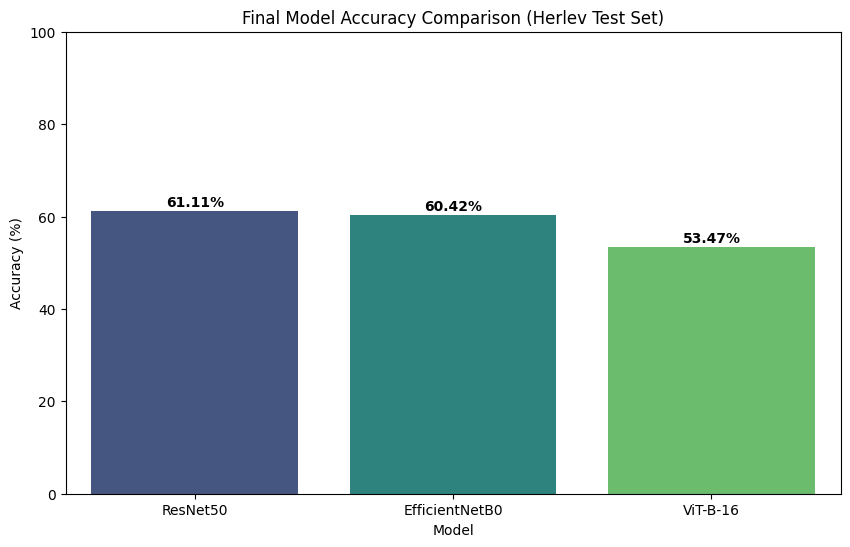

In [22]:
import seaborn as sns

# Convert percentage strings to floats for plotting
comparison_df['Acc_Float'] = comparison_df['Test Accuracy'].str.rstrip('%').astype('float')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Acc_Float', data=comparison_df, palette='viridis')
plt.title('Final Model Accuracy Comparison (Herlev Test Set)')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100) # Keep scale consistent
for i, val in enumerate(comparison_df['Acc_Float']):
    plt.text(i, val + 1, f"{val}%", ha='center', fontweight='bold')
plt.show()